In [1]:
import pandas as pd
import numpy as np 
import en_core_web_sm
import spacy

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
data = pd.read_csv('data.csv')
data.head()

,id,description
0,1,Active classic boxers - There's a reason why o...
1,2,Active sport boxer briefs - Skinning up Glory ...
2,3,Active sport briefs - These superbreathable no...
3,4,"Alpine guide pants - Skin in, climb ice, switc..."
4,5,"Alpine wind jkt - On high ridges, steep ice an..."


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           500 non-null    int64 
 1   description  500 non-null    object
dtypes: int64(1), object(1)
memory usage: 7.9+ KB


In [4]:
data.isnull().sum() / len(data) * 100

id             0.0
description    0.0
dtype: float64

In [5]:
data['desc_clean'] = data['description'].str.replace(r"<[^>]*>", " ", regex=True)
data['desc_clean'] = data['desc_clean'].str.replace(r"[^A-Za-z0-9 ]+", " ", regex = True)
data['desc_clean'] = data['desc_clean'].str.replace(r"\s+", " ", regex = True)
data['desc_clean'] = data['desc_clean'].fillna('').apply(lambda x: x.lower())
data.head()

,id,description,desc_clean
0,1,Active classic boxers - There's a reason why o...,active classic boxers there s a reason why our...
1,2,Active sport boxer briefs - Skinning up Glory ...,active sport boxer briefs skinning up glory re...
2,3,Active sport briefs - These superbreathable no...,active sport briefs these superbreathable no f...
3,4,"Alpine guide pants - Skin in, climb ice, switc...",alpine guide pants skin in climb ice switch to...
4,5,"Alpine wind jkt - On high ridges, steep ice an...",alpine wind jkt on high ridges steep ice and a...


In [6]:
nlp = en_core_web_sm.load()

In [7]:
from spacy.lang.en.stop_words import STOP_WORDS

data['desc_token_temp'] = data['desc_clean'].apply(
    lambda x: [token.lemma_ for token in nlp(x) if token.text.lower() not in STOP_WORDS]
)
data['nlp_ready_temp'] = data['desc_token_temp'].apply(lambda x: ' '.join(x))

vectorizer_temp = TfidfVectorizer(stop_words='english')
X_temp = vectorizer_temp.fit_transform(data['nlp_ready_temp'])
feature_names = vectorizer_temp.get_feature_names_out()
mean_tfidf = X_temp.mean(axis=0).A1

vec = CountVectorizer()
X_count = vec.fit_transform(data['nlp_ready_temp'])
doc_freq = np.asarray(X_count.sum(axis=0)).ravel() / X_count.shape[0]
words_high_freq = [word for word, freq in zip(vec.get_feature_names_out(), doc_freq) if freq > 0.7]

threshold = 0.008
low_info_words = [word for word, score in zip(feature_names, mean_tfidf) if score < threshold]

combined_stopwords = STOP_WORDS.union(set(low_info_words)).union(set(words_high_freq))

data['desc_token'] = data['desc_clean'].apply(
    lambda x: [token.lemma_ for token in nlp(x)
            if token.text.lower() not in combined_stopwords
            and token.lemma_.lower() not in combined_stopwords]
)
data['nlp_ready'] = data['desc_token'].apply(lambda x: ' '.join(x))

final_vectorizer = TfidfVectorizer(stop_words=None)
X = final_vectorizer.fit_transform(data['nlp_ready'])
X


<500x182 sparse matrix of type '<class 'numpy.float64'>'
	with 11801 stored elements in Compressed Sparse Row format>

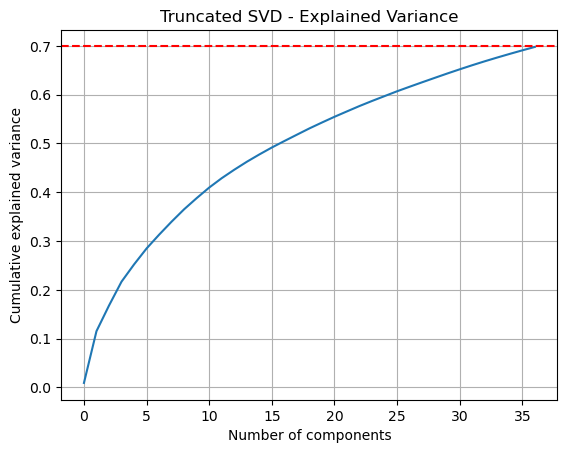

In [8]:
svd = TruncatedSVD(n_components=37)
svd.fit(X)

explained = np.cumsum(svd.explained_variance_ratio_)

plt.plot(explained)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.grid()
plt.title("Truncated SVD - Explained Variance")
plt.axhline(0.70, color='red', linestyle='--')
plt.show()

In [9]:
svd_components = 37
svd_model = TruncatedSVD(n_components=svd_components, algorithm='randomized', n_iter=100)
lsa = svd_model.fit_transform(X)
lsa

array([[ 3.42381210e-01, -1.52970692e-01, -2.96782997e-01, ...,
         6.03300447e-02, -6.36856572e-02, -7.72378356e-02],
       [ 4.09748970e-01, -1.52708227e-01, -2.33713183e-01, ...,
         3.40656628e-02, -8.03903419e-02,  5.65151898e-02],
       [ 3.46395279e-01, -1.61482630e-01, -8.67047999e-02, ...,
        -4.12702728e-03, -8.41173822e-03,  7.00177405e-02],
       ...,
       [ 3.52356586e-01, -2.39697121e-01,  4.12192309e-01, ...,
        -1.23993618e-01,  2.90711455e-02, -7.58336150e-05],
       [ 2.81546508e-01, -1.15655260e-01, -3.09881808e-01, ...,
        -8.52216945e-02, -1.27942843e-02,  2.06734502e-03],
       [ 3.10993615e-01, -1.36677294e-01, -2.95566070e-01, ...,
        -6.69582209e-02,  1.23398601e-02, -5.88311798e-03]])

In [10]:
topic_df = pd.DataFrame(lsa, columns=["topic {}".format(i+1) for i in range(svd_components)], index=data.index)
topic_df['desc'] = data['nlp_ready'].values
topic_df

,topic 1,topic 2,topic 3,topic 4,topic 5,topic 6,topic 7,topic 8,topic 9,topic 10,...,topic 29,topic 30,topic 31,topic 32,topic 33,topic 34,topic 35,topic 36,topic 37,desc
0,0.342381,-0.152971,-0.296783,-0.136954,-0.119574,0.173444,-0.092567,0.126531,-0.331156,-0.053193,...,0.101113,0.153425,-0.032186,-0.000596,0.016689,0.041722,0.060330,-0.063686,-0.077238,classic s cool quick lightweight pack waistban...
1,0.409749,-0.152708,-0.233713,0.034544,0.089636,0.026922,-0.206995,0.155338,-0.173261,0.034530,...,0.026379,-0.073997,0.081000,0.136066,-0.148236,-0.045440,0.034066,-0.080390,0.056515,skin breathable s fast dry 7 spandex stretch w...
2,0.346395,-0.161483,-0.086705,-0.090590,0.168399,-0.108168,-0.174078,0.241944,-0.004578,-0.061349,...,-0.087118,-0.174937,-0.054479,0.090652,-0.039238,-0.047430,-0.004127,-0.008412,0.070018,fly s high blend fast quick 7 spandex stretch ...
3,0.438674,-0.269930,0.258325,0.004507,0.090862,0.015718,-0.075423,-0.047254,-0.098618,0.044749,...,0.150868,0.027599,0.062074,-0.092580,-0.173663,-0.132092,0.036034,-0.075262,-0.084866,skin resistant breathable shell stretch t inte...
4,0.482924,-0.273053,0.331598,-0.115396,0.070579,-0.027859,-0.051341,0.111964,-0.014639,0.050795,...,-0.039791,-0.096529,-0.103841,-0.064394,-0.084627,0.073689,-0.086059,-0.119224,-0.003533,wind high shell cool high s time tie ripstop s...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.314925,-0.129449,-0.312642,-0.329412,-0.199043,0.151065,-0.037692,0.076791,-0.509215,-0.073718,...,0.014671,-0.026391,0.006762,-0.055102,0.020330,0.021697,0.025196,0.062837,-0.013272,2 capilene 2 fast performance lightweight t op...
496,0.343245,-0.117502,-0.291166,-0.504213,-0.248245,0.130426,0.034594,0.115824,-0.331411,-0.151157,...,-0.082255,-0.153397,0.093675,-0.061050,0.001350,-0.027045,-0.022859,-0.109534,0.016692,2 fast dry time performance open knit construc...
497,0.352357,-0.239697,0.412192,-0.109831,-0.023030,0.112703,0.171632,-0.377059,-0.038140,-0.001517,...,-0.007330,-0.061322,0.092471,-0.059210,-0.036399,0.175164,-0.123994,0.029071,-0.000076,time shell time time finish shell provide leng...
498,0.281547,-0.115655,-0.309882,0.385487,-0.158051,0.291499,0.065517,0.045330,-0.027205,-0.046614,...,-0.024579,-0.036997,0.179519,0.083111,-0.015363,-0.102692,-0.085222,-0.012794,0.002067,wear wear time garment wash 5 2 canvas t chafe...


# KMeans

In [11]:
wcss = []
k_range = range(2, 20)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(lsa)
    wcss.append(kmeans.inertia_)

print(wcss)

[263.87763679425007, 245.03049352613363, 250.23696073083957, 218.1630284097864, 201.75984092551482, 192.98517101156767, 186.07666358538347, 175.74878263152465, 167.61788018163617, 160.01523952039685, 152.84631252644164, 147.66856359365858, 139.47837121033865, 138.58915035241068, 133.3437066229854, 128.32353936320385, 124.883173681496, 122.86545297024226]


In [12]:
fig = px.line(x= k_range, y = wcss)
fig.show()

In [13]:
s_score = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(lsa)
    s_score.append(silhouette_score(lsa, kmeans.predict(lsa)))

print(s_score)

[0.1829764362477552, 0.14485331268031285, 0.1162643046862705, 0.17910898634854322, 0.20165441899689024, 0.21210359804592752, 0.21140045732172513, 0.22970128754009939, 0.23799987789494506, 0.24958695810229664, 0.2555700658219883, 0.26081051767560387, 0.27598372409641636, 0.2672942820633667, 0.2743643015599581, 0.28256032094416456, 0.2837016625492901, 0.2832867480874851]


In [14]:
fig = px.bar(x= k_range, y = s_score)
fig.show()

In [15]:
kmeans = KMeans(n_clusters=14)
kmeans.fit(lsa)

KMeans(n_clusters=14)

In [16]:
df_kmeans = data.copy()
df_kmeans = df_kmeans.drop(columns=['desc_clean', 'desc_token_temp', 'nlp_ready_temp', 'desc_token'])
df_kmeans['kmeans_cluster'] = kmeans.predict(lsa)
df_kmeans.head()

,id,description,nlp_ready,kmeans_cluster
0,1,Active classic boxers - There's a reason why o...,classic s cool quick lightweight pack waistban...,10
1,2,Active sport boxer briefs - Skinning up Glory ...,skin breathable s fast dry 7 spandex stretch w...,0
2,3,Active sport briefs - These superbreathable no...,fly s high blend fast quick 7 spandex stretch ...,8
3,4,"Alpine guide pants - Skin in, climb ice, switc...",skin resistant breathable shell stretch t inte...,6
4,5,"Alpine wind jkt - On high ridges, steep ice an...",wind high shell cool high s time tie ripstop s...,6


In [17]:
df_kmeans['kmeans_cluster'].value_counts()

kmeans_cluster
1     69
5     52
2     50
6     48
13    48
10    34
0     32
7     31
11    31
3     25
9     22
8     20
4     20
12    18
Name: count, dtype: int64

In [18]:
chart_svd_2d = TruncatedSVD(n_components=2, random_state=42)
chart_data_2d = chart_svd_2d.fit_transform(lsa)
chart_data_2d

array([[ 3.42381825e-01, -1.52969816e-01],
       [ 4.09749838e-01, -1.52708624e-01],
       [ 3.46395934e-01, -1.61482778e-01],
       [ 4.38674230e-01, -2.69931020e-01],
       [ 4.82924032e-01, -2.73054048e-01],
       [ 4.70492186e-01, -2.33541802e-01],
       [ 3.67104750e-01, -8.77151671e-02],
       [ 1.77226584e-01,  6.85051041e-03],
       [ 2.86506567e-01, -1.16432483e-01],
       [ 3.64936593e-01, -3.36911860e-02],
       [ 2.76742512e-01, -8.43440209e-02],
       [ 3.41457066e-01, -2.16324610e-01],
       [ 3.18271310e-01, -1.66183554e-01],
       [ 2.15203292e-01, -8.61148044e-02],
       [ 4.85894300e-01, -2.87760180e-01],
       [ 4.22138447e-01, -2.51684518e-01],
       [ 3.16805957e-01, -1.62560473e-01],
       [ 3.78171868e-01, -1.70823460e-01],
       [ 2.83042330e-01, -1.26266084e-01],
       [ 3.64060636e-01, -1.14857415e-01],
       [ 3.62177574e-01, -9.35840124e-02],
       [ 3.29372744e-01, -1.01193538e-01],
       [ 3.53944295e-01, -1.20597803e-01],
       [ 3.

In [19]:
chart_df_2d = pd.DataFrame(chart_data_2d, columns=['topic 1', 'topic 2'])
chart_df_2d["cluster"] = df_kmeans["kmeans_cluster"]
chart_df_2d.head()

,topic 1,topic 2,cluster
0,0.342382,-0.152970,10
1,0.409750,-0.152709,0
2,0.346396,-0.161483,8
3,0.438674,-0.269931,6
4,0.482924,-0.273054,6


In [20]:
fig = px.scatter(chart_df_2d, x='topic 1', y='topic 2', color='cluster')
fig.show()

In [21]:
chart_svd_3d = TruncatedSVD(n_components=3, random_state=42)
chart_data_3d = chart_svd_3d.fit_transform(lsa)
chart_data_3d

array([[ 0.34238119, -0.1529717 , -0.29679606],
       [ 0.40974899, -0.15271529, -0.23387499],
       [ 0.3463954 , -0.16149298, -0.08698757],
       ...,
       [ 0.35235665, -0.23969775,  0.41211753],
       [ 0.28154667, -0.11565692, -0.31000556],
       [ 0.31099373, -0.1366792 , -0.29568275]])

In [22]:
chart_df_3d = pd.DataFrame(chart_data_3d, columns=['topic 1', 'topic 2', 'topic 3'])
chart_df_3d["cluster"] = df_kmeans["kmeans_cluster"]
chart_df_3d.head()

,topic 1,topic 2,topic 3,cluster
0,0.342381,-0.152972,-0.296796,10
1,0.409749,-0.152715,-0.233875,0
2,0.346395,-0.161493,-0.086988,8
3,0.438674,-0.269928,0.258408,6
4,0.482924,-0.273051,0.331610,6


In [23]:
fig = px.scatter_3d(chart_df_3d, x='topic 1', y='topic 2', z='topic 3', color='cluster')
fig.show()

In [24]:
from wordcloud import WordCloud

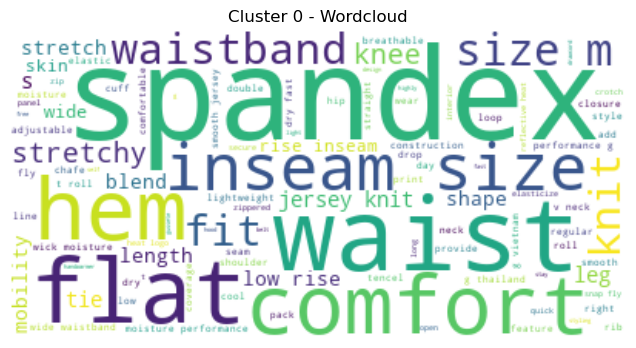

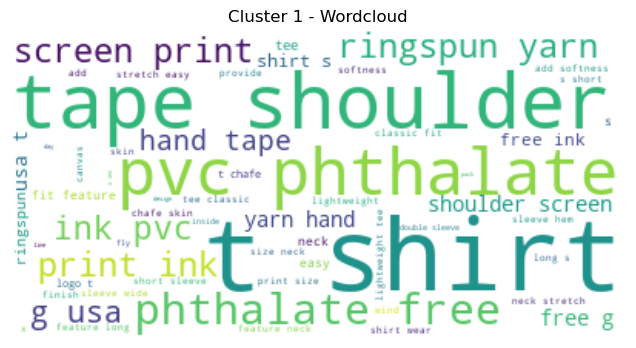

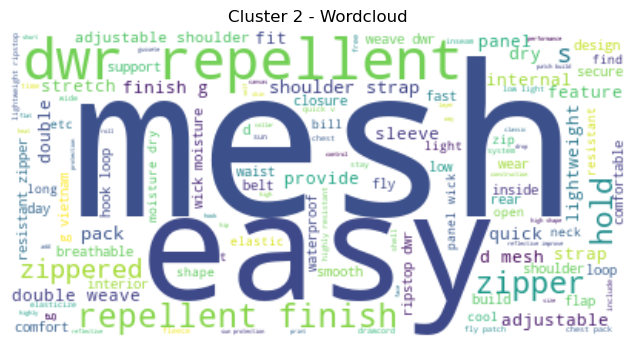

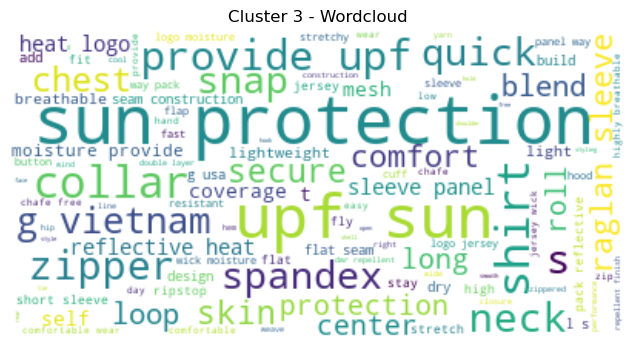

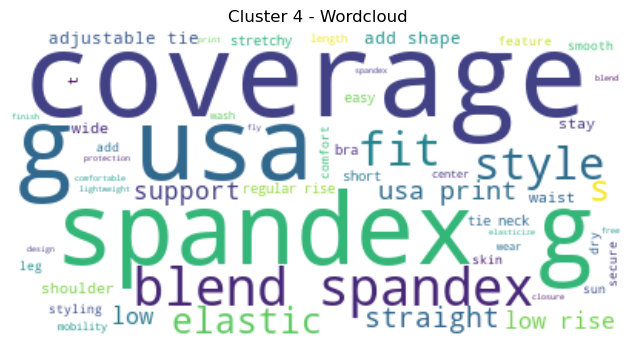

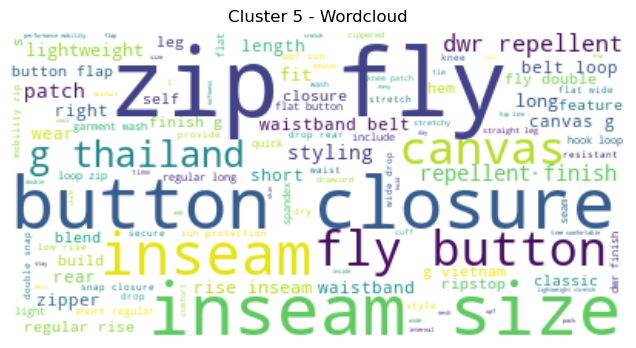

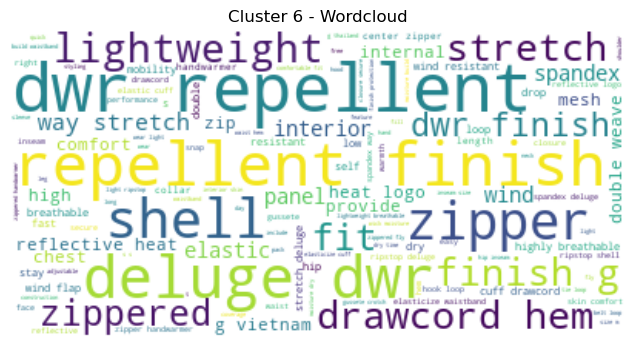

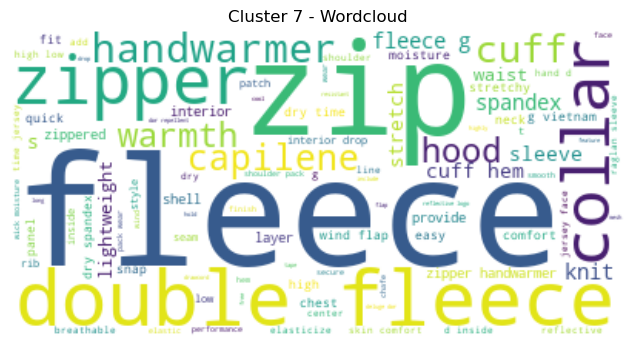

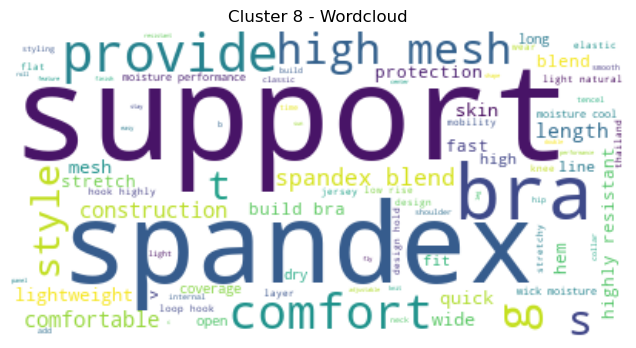

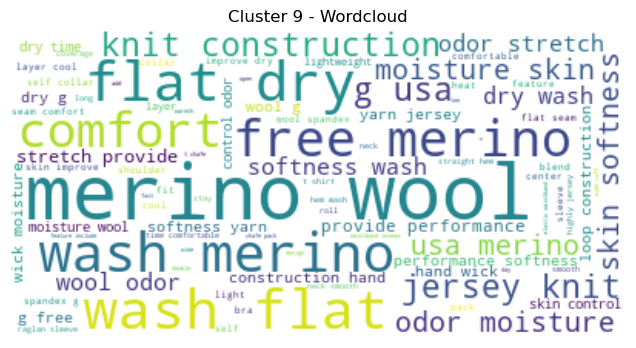

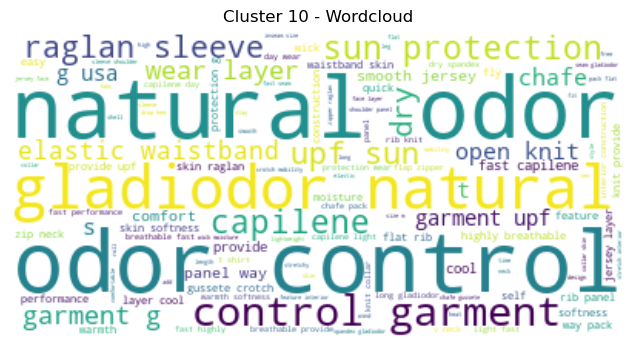

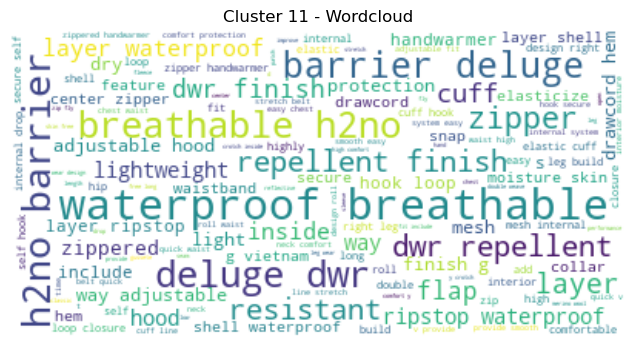

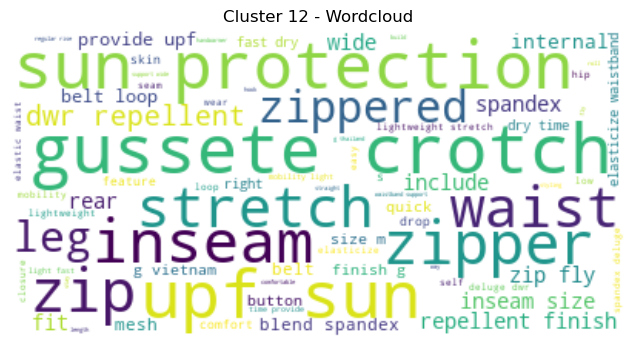

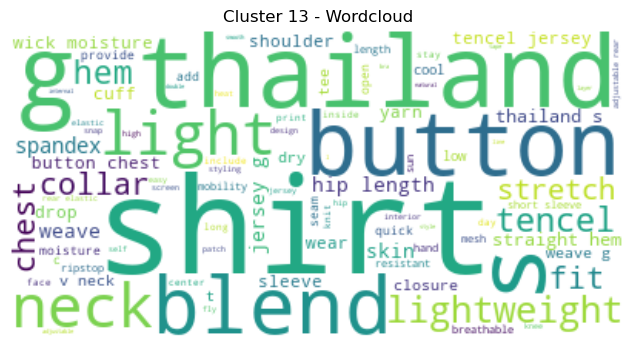

In [25]:
for i in sorted(df_kmeans['kmeans_cluster'].unique()):
    text = " ".join(df_kmeans[df_kmeans['kmeans_cluster'] == i]['nlp_ready'])
    wordcloud = WordCloud(background_color='white').generate(text)
    
    plt.figure(figsize=(10, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Cluster {i} - Wordcloud")
    plt.show()

In [26]:
from sklearn.metrics import silhouette_score

score = silhouette_score(lsa, kmeans.labels_)
print(f"Silhouette score: {score:.2f}")

Silhouette score: 0.26


# DBscan

In [27]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

# Liste pour stocker les résultats
results = []

eps_values = np.arange(0.05, 0.5, 0.05)
min_samples_values = range(5, 20, 1)

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine')
        labels = db.fit_predict(lsa)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        noise_pct = n_noise / len(labels) * 100

        if n_clusters > 1:
            sil_score = silhouette_score(lsa, labels, metric='cosine')
        else:
            sil_score = -1 

        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'silhouette': sil_score,
            'noise_pct': noise_pct
        })

results_df = pd.DataFrame(results)
results_df.sort_values(by='silhouette', ascending=False, inplace=True)
results_df.head(10) 


,eps,min_samples,n_clusters,silhouette,noise_pct
60,0.25,5,20,0.361108,18.0
76,0.30,6,16,0.353227,10.2
77,0.30,7,14,0.346969,14.6
62,0.25,7,17,0.342579,28.2
61,0.25,6,18,0.341402,23.6
82,0.30,12,11,0.330416,30.4
63,0.25,8,16,0.325812,31.0
45,0.20,5,27,0.325471,30.2
78,0.30,8,13,0.324754,18.6
79,0.30,9,11,0.324009,22.0


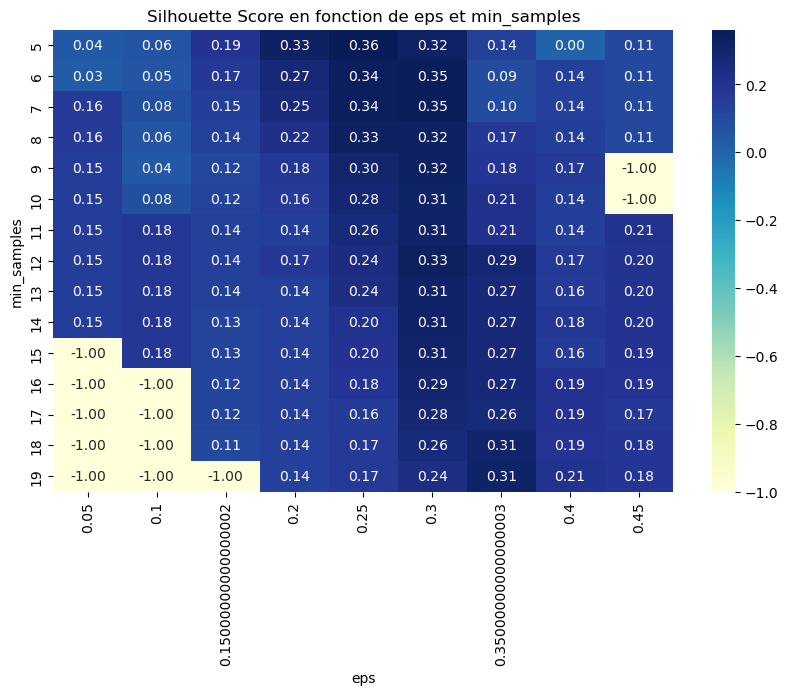

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = results_df.pivot(index='min_samples', columns='eps', values='silhouette')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Silhouette Score en fonction de eps et min_samples")
plt.show()

In [29]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.25, min_samples=5, metric="cosine")

db.fit(lsa)

np.unique(db.labels_)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19])

In [33]:
df_dbscan = data.copy()
df_dbscan = df_dbscan.drop(columns=['desc_clean', 'desc_token_temp', 'nlp_ready_temp', 'desc_token'])
df_dbscan['db_cluster'] = db.fit_predict(lsa)

df_dbscan.head()

,id,description,nlp_ready,db_cluster
0,1,Active classic boxers - There's a reason why o...,classic s cool quick lightweight pack waistban...,0
1,2,Active sport boxer briefs - Skinning up Glory ...,skin breathable s fast dry 7 spandex stretch w...,1
2,3,Active sport briefs - These superbreathable no...,fly s high blend fast quick 7 spandex stretch ...,1
3,4,"Alpine guide pants - Skin in, climb ice, switc...",skin resistant breathable shell stretch t inte...,2
4,5,"Alpine wind jkt - On high ridges, steep ice an...",wind high shell cool high s time tie ripstop s...,3


In [34]:
df_dbscan['db_cluster'].value_counts()

db_cluster
-1     90
 7     62
 8     61
 0     34
 3     31
 9     31
 4     28
 11    24
 13    24
 6     21
 5     20
 12    12
 16    10
 17    10
 10     8
 1      7
 18     6
 15     6
 14     5
 2      5
 19     5
Name: count, dtype: int64

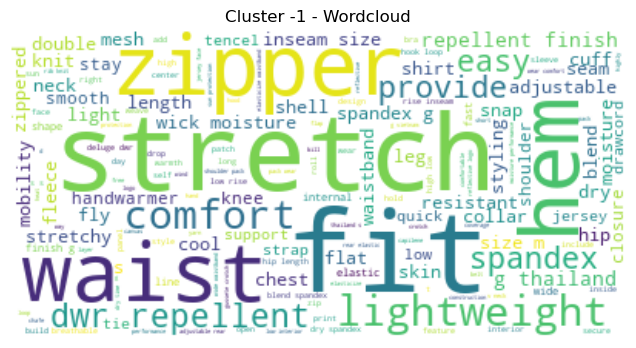

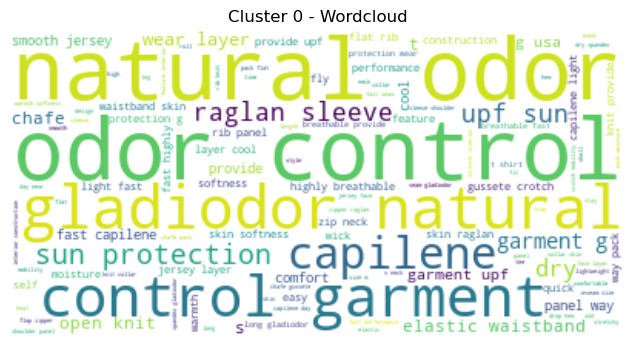

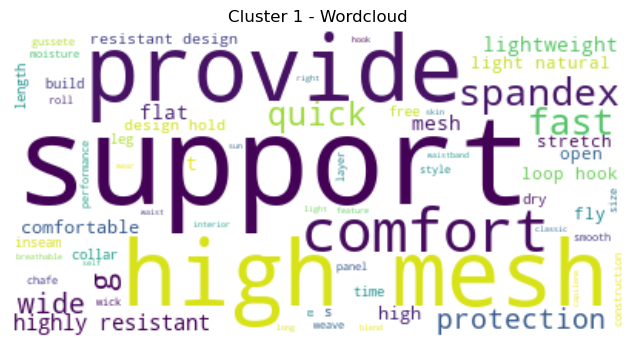

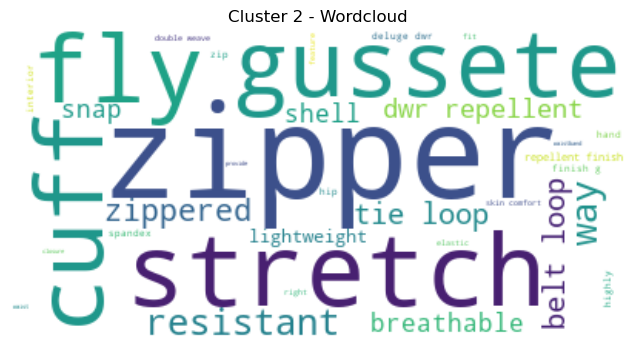

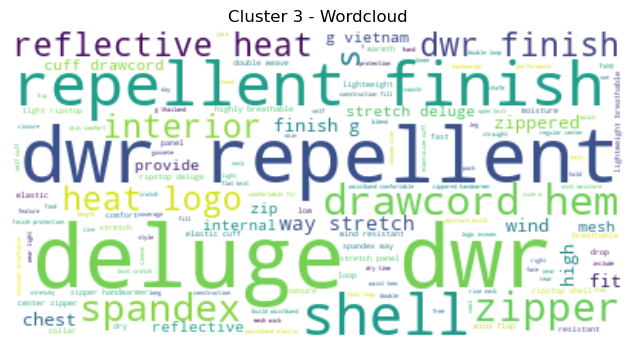

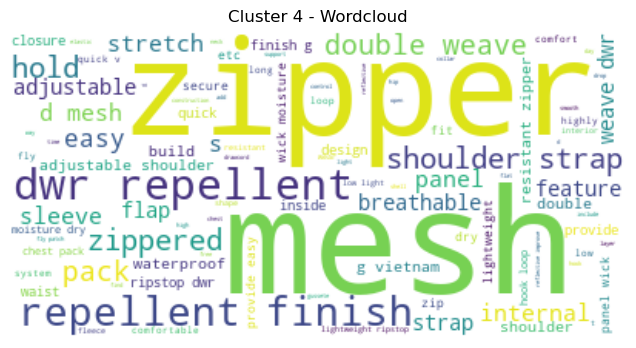

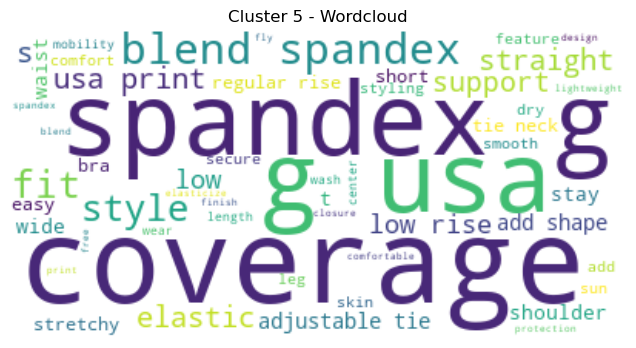

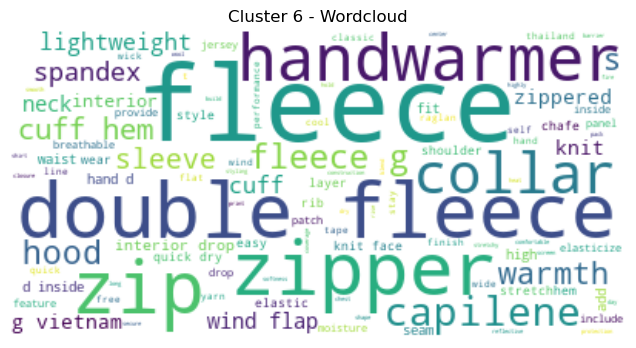

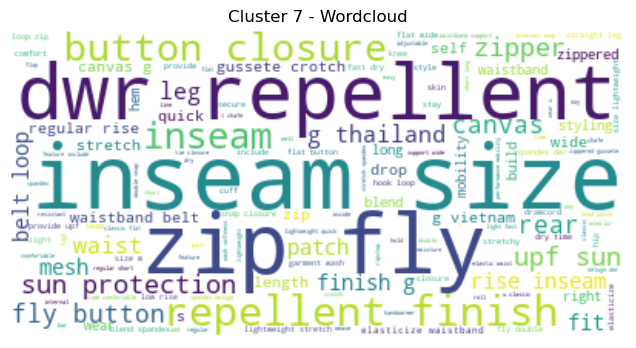

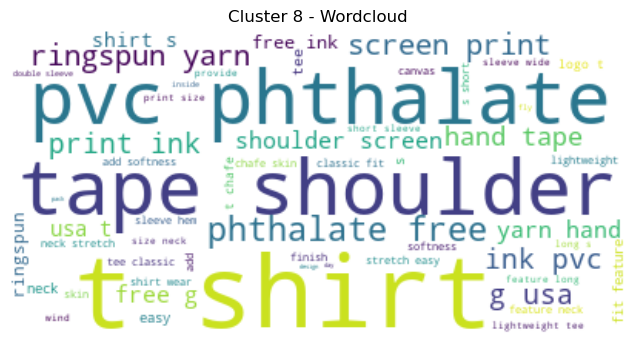

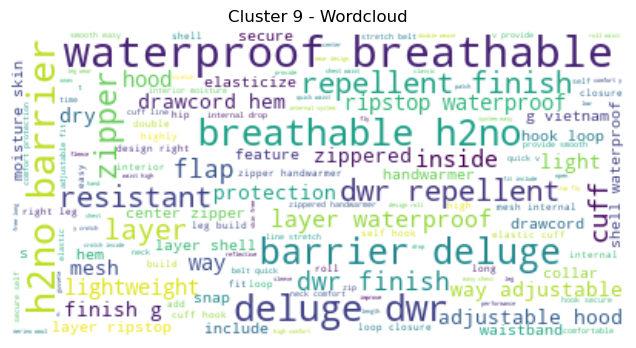

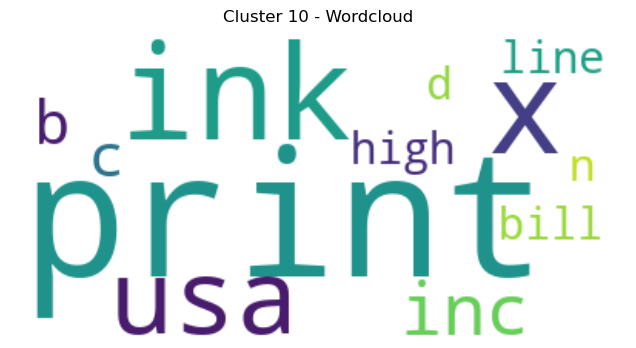

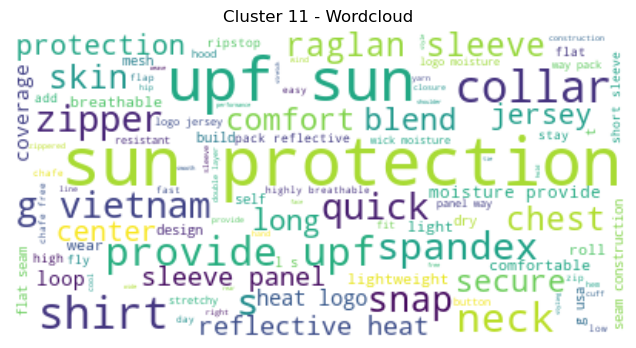

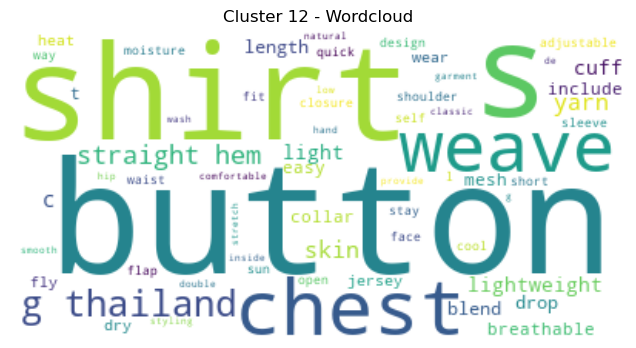

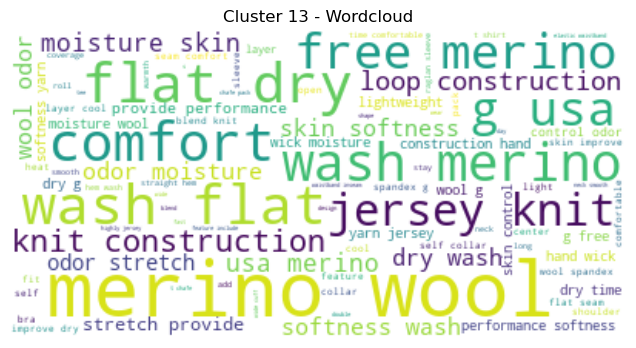

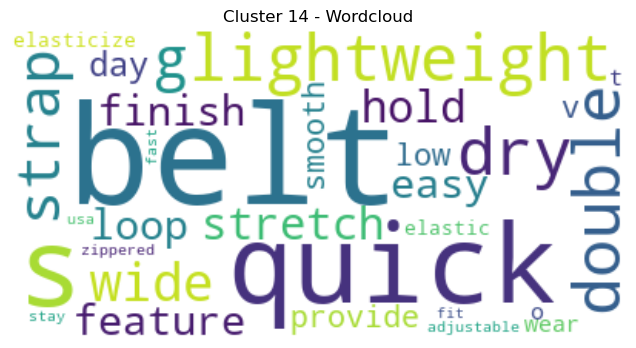

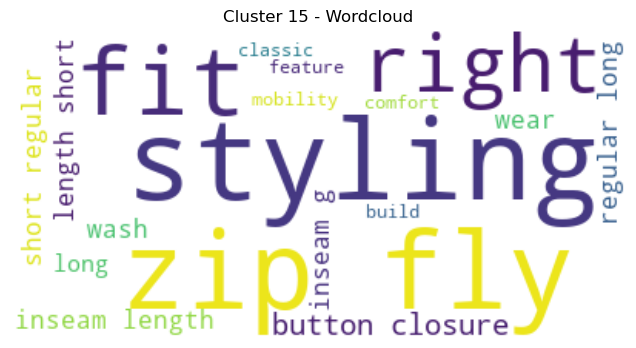

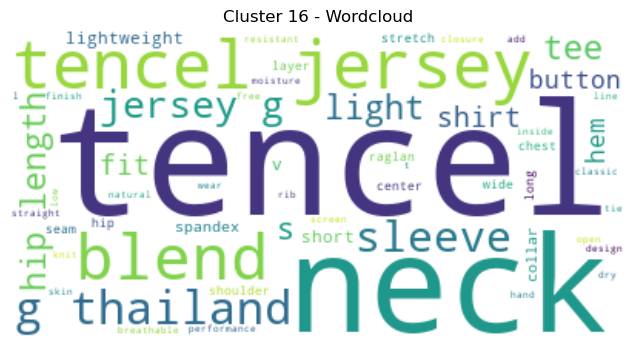

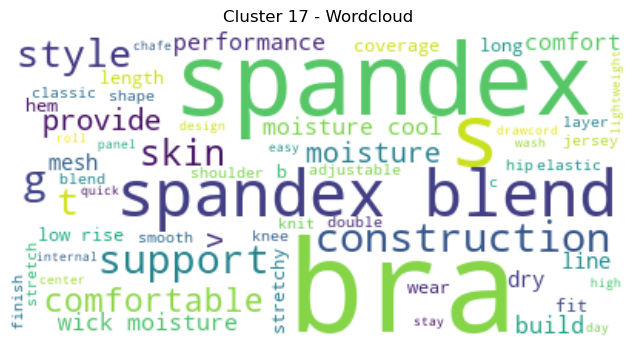

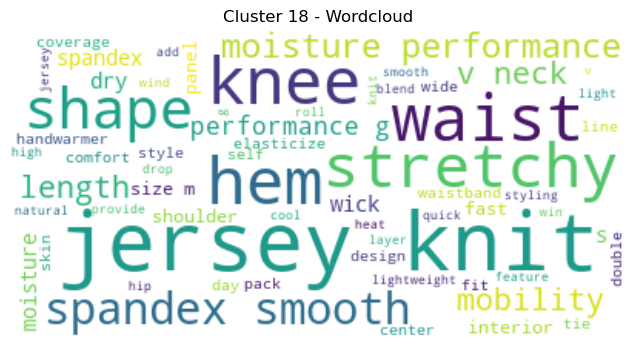

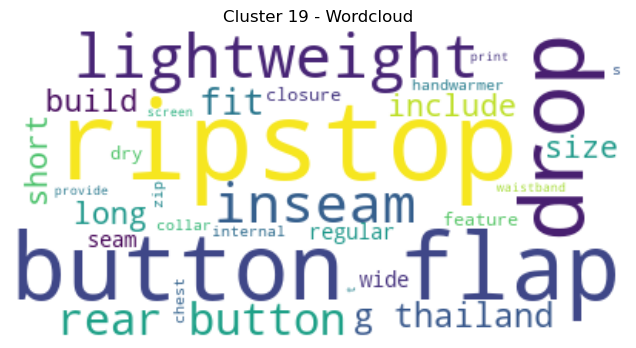

In [35]:
for i in sorted(df_dbscan['db_cluster'].unique()):
    text = " ".join(df_dbscan[df_dbscan['db_cluster'] == i]['nlp_ready'])
    wordcloud = WordCloud(background_color='white').generate(text)
    
    plt.figure(figsize=(10, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Cluster {i} - Wordcloud")
    plt.show()

In [55]:
def find_similar_items(item_id):
    if item_id in df_dbscan['id'].values:
        current_item = df_dbscan[df_dbscan['id'] == item_id]
        current_cluster = current_item['db_cluster'].values[0]
        other_cluster_item = df_dbscan[df_dbscan['db_cluster'] == current_cluster]

        return other_cluster_item.sample(5)
    else:
        print(item_id, 'is not defined as ID')
        return []

find_similar_items(42)

,id,description,nlp_ready,db_cluster
193,194,"Lithia skirt - After packing the quiver, who h...",s lightweight tencel line double waistband tie...,-1
352,353,"Simple guide pants - A staple for rock, ice an...",shell light stretch pant spandex double weave ...,-1
48,49,Great divider - From standing waves to blue-wa...,wind s win chest double waterproof protection ...,-1
180,181,Elsa top - When shade-seeking at Nine Palms st...,time lightweight wear shoulder sleeve add hip ...,-1
284,285,Ester top - Throw on the Ester Top for a quick...,quick low style light s v neck styling open he...,-1


In [67]:
def get_valid_item_id():
    while True:
        user_input = input("What's your items ID?")
        try:
            user_item_id = int(user_input)
            return user_item_id
        except ValueError:
            print("Please enter a valid number.")


user_item_id = get_valid_item_id()
find_similar_items(user_item_id)

,id,description,nlp_ready,db_cluster
399,400,Retro grade shorts - As advantageous as a numb...,2 blend 2 spandex stay cool skin gussete crotc...,-1
294,295,"Vasana top - The stretchy, sleeveless Vasana o...",stretchy shoulder coverage shoulder 10 spandex...,-1
325,326,Thrift shorts - The unofficial short for those...,short support light wear blend open weave rear...,-1
380,381,"R2 jkt - A modern mountain staple, the adaptab...",layer layer shell stretchy knit length warmth ...,-1
246,247,Serenity tights - Soft and stretchy for unrest...,stretchy mobility fit waist adjustable waist r...,-1
